# cEBMF demo using a "tiled-clustering" data set

This example is similar to the example presented in Figure 1 in "Covariate-moderated Empirical Bayes Matrix Factorization" (Denault et al, 2025).

In this example, we simulate a matrix ${\bf Z} = {\bf L}{\bf F}^T$, in which ${\bf L}$ (but not ${\bf F}$) depends on the 2-d locations of the data points. Specifically, we generate a periodic tiling of $[0,1] \times [0,1]$, randomly labeling each tile 1, 2 or 3. For each data point $i$, we set $l_{ik} = f(x,y)$ if $i$ was in the tile with label $k$, otherwise $l_{ik} = 0$. The ${\bf F}$ matrix, by contrast, is simulated from a scale mixture of normals, $f_{jk} \sim \pi_0 \delta_0 + \sum_{m=1}^M N(0, \sigma_m^2)$.

We simulate homoskedastic noise, $\tau_{ij} = 0.1$.

In [ ]:
!cd /content
!wget https://codeload.github.com/william-denault/cebmf_torch/zip/refs/heads/main
!unzip main
!cd cebmf_torch-main; pip install .

In [ ]:
!cd /content/cebmf_torch-main; pwd

To run the example, start by loading PyTorch and MatPlotLib:

In [19]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

These parameters control how the data are simulated:

In [20]:
SEED = 1
N = 2000         # number of (x,y) points
M = 200           # number of features (columns) in f
BOUNDARIES = (0.33, 0.66)  # vertical/horizontal guide lines
NOISE_STD = 1.0   # std-dev for observation noise in Z
torch.manual_seed(SEED)

Simulate the x and y co-ordinates of the data:

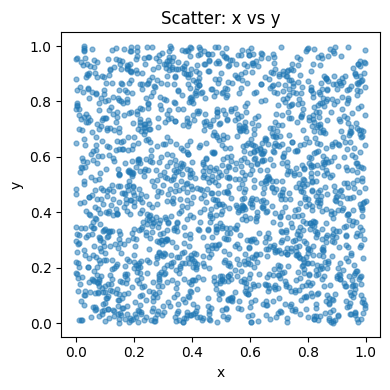

In [21]:
x = torch.rand(N)
y = torch.rand(N)
X = torch.stack([x, y], dim=1)  # (N, 2) -- kept for clarity/optionally used later
plt.figure(figsize=(4, 4))
plt.scatter(x.numpy(), y.numpy(), alpha=0.5, s=12)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter: x vs y")
plt.tight_layout()
plt.show()

Simulate ${\bf L}$ and ${\bf F}$:

Text(0, 0.5, 'y')

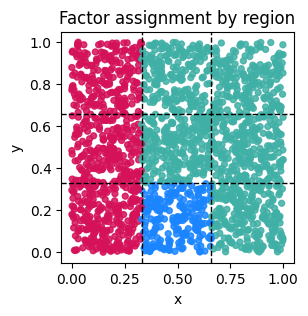

In [22]:
# =========================
# 2) Generate f (3 x M)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# =========================
t1 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}
t2 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}

f0 = t1 * torch.randn(M)
f1 = t2 * torch.randn(M)
f2 = t2 * torch.randn(M)
f  = torch.stack([f0, f1, f2], dim=0)  # (3, M)

# =========================
# 3) Build L (N x 3) + factor labels
# =========================
L = torch.zeros(N, 3, dtype=torch.float32)

b1, b2 = BOUNDARIES
mask1 = x < b1
mask2 = (~mask1) & (x < b2) & (y < b1)  # second region
mask3 = ~(mask1 | mask2)                # everything else

# Nonzero loadings by region (note: original logic used sin(x) for all three)
L[mask1, 0] = torch.sin(x[mask1])
L[mask2, 1] = torch.sin(x[mask2])
L[mask3, 2] = torch.sin(x[mask3])

# Integer factor labels in {1,2,3}
factor = torch.zeros(N, dtype=torch.long)
factor[mask1] = 1
factor[mask2] = 2
factor[mask3] = 3

# =========================
# 4) Factor visualization
# =========================
colors = ["#D41159", "#1A85FF", "#40B0A6"]  # red, blue, teal
color_map = {1: colors[0], 2: colors[1], 3: colors[2]}
point_colors = [color_map[int(k)] for k in factor.tolist()]

plt.figure(figsize=(3, 3))
plt.scatter(x.numpy(), y.numpy(), c=point_colors, s=18, alpha=0.85)
for v in (b1, b2):
    plt.axhline(v, color="black", linestyle="--", linewidth=1)
    plt.axvline(v, color="black", linestyle="--", linewidth=1)
plt.title("Factor assignment by region")
plt.xlabel("x")
plt.ylabel("y")

Show the membership (${\bf L}$) matrices:

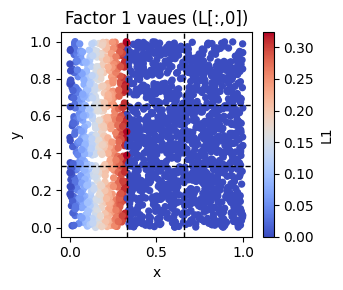

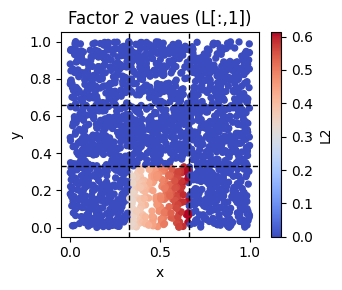

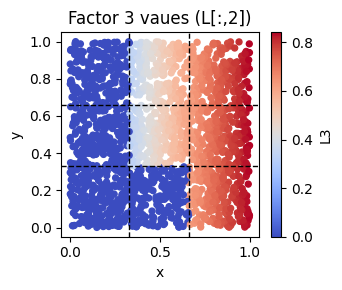

In [23]:
for i in range(3):
    plt.figure(figsize=(3.5,3))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=L[:, i].numpy(),
        cmap="coolwarm",  # shows magnitude of L[:,i]
        s=18
    )
    for v in (b1, b2):
        plt.axhline(v, color="black", linestyle="--", linewidth=1)
        plt.axvline(v, color="black", linestyle="--", linewidth=1)
    plt.title(f"Factor {i+1} vaues (L[:,{i}])")
    plt.xlabel("x")
    plt.ylabel("y")
    cbar = plt.colorbar()
    cbar.set_label(f"L{i+1}")
    plt.tight_layout()
    plt.show()

Simulate ${\bf Z}$:

In [24]:
noise = NOISE_STD * torch.randn(N, M)
Z = L @ f + noise  # (N, M)

We will factorize the matrix Z using 4 different models.


1. EBMF using point mass Laplace without using side information.

2. cEBMF using a *covariate moderated adaptive shrinkage prior* (cash) $g(x,y) = \pi_0(x,y) \delta_0 + \sum_{m=1}^M \pi_m (x,y) N(0, \sigma_m^2)$.

3. cEBMF using a *covariate moderated generalized binary prior* (cgb) $g(x,y) = \pi_0(x,y) \delta_0 + (1-\pi_0(x,y))  N(\mu, \sigma_m^2)$.

4. cEBMF using a *emprirical mixture of density networks* (emdn) $ g(x,y) = \sum_{m=1}^M \pi_m (x,y) N(\mu(x,y), \sigma_m(x,y)^2)$.

Let's begin with Model 1, where we learn a matrix factorization without accounting for the 2-d side information:

In [25]:
from cebmf_torch import cEBMF
mycebmf = cEBMF(data = Z)
mycebmf.initialise_factors()
mycebmf.fit(10)

CEBMFResult(L=tensor([[-6.7596e+00, -1.4331e-02,  1.8321e+00,  7.1684e-09, -1.5489e-07],
        [-1.2728e-01, -8.6279e-02,  2.0285e+00,  6.1395e-08, -6.4827e-08],
        [-1.6565e+00, -1.5823e-02, -1.1584e-02, -3.5872e-08, -4.0809e-07],
        ...,
        [-6.3493e+00, -9.7499e-01,  1.8473e-02, -1.5639e-08,  4.7177e-07],
        [-1.1015e-01,  6.2749e-02,  2.8441e+00,  7.1832e-08, -1.0763e-08],
        [-9.9252e-02,  1.2566e-01,  1.3082e+00, -2.2410e-08,  6.1775e-08]],
       device='cuda:0'), F=tensor([[-1.3574e-01,  1.4970e-01, -8.4929e-02,  1.3982e-20, -8.7245e-20],
        [ 1.6497e-01,  1.4325e-01,  3.9474e-04,  3.4144e-22, -4.5316e-20],
        [-5.1117e-04, -6.7894e-04,  5.7606e-02,  1.0119e-20, -2.4195e-19],
        [-5.5548e-02,  1.2525e-01,  6.6626e-02, -5.5111e-20,  1.9835e-20],
        [ 1.5924e-05, -2.8375e-02,  6.6556e-02, -8.7552e-20, -6.5381e-20],
        [ 1.1018e-03,  1.7564e-03, -4.5967e-04,  4.9006e-21,  1.2452e-20],
        [-1.2126e-05, -9.3932e-03, -5.1897e-0

Model 2 incorporates the side information into a "covariate-moderated" variant of the generalized binary prior:

[CGB] Epoch 10/50, Loss=8.7838, mu2=-0.154, sigma2=0.933
[CGB] Epoch 20/50, Loss=8.5643, mu2=-0.307, sigma2=0.871
[CGB] Epoch 30/50, Loss=8.3925, mu2=-0.462, sigma2=0.899
[CGB] Epoch 40/50, Loss=8.1691, mu2=-0.618, sigma2=0.819
[CGB] Epoch 50/50, Loss=7.9505, mu2=-0.774, sigma2=0.799
[CGB] Epoch 10/50, Loss=2.4842, mu2=-0.153, sigma2=0.622
[CGB] Epoch 20/50, Loss=2.3312, mu2=-0.322, sigma2=0.515
[CGB] Epoch 30/50, Loss=2.2646, mu2=-0.484, sigma2=0.587
[CGB] Epoch 40/50, Loss=2.2117, mu2=-0.640, sigma2=0.472
[CGB] Epoch 50/50, Loss=2.1768, mu2=-0.792, sigma2=0.568
[CGB] Epoch 10/50, Loss=2.2722, mu2=0.058, sigma2=0.344
[CGB] Epoch 20/50, Loss=2.2727, mu2=0.061, sigma2=0.313
[CGB] Epoch 30/50, Loss=2.2640, mu2=0.061, sigma2=0.367
[CGB] Epoch 40/50, Loss=2.2690, mu2=0.061, sigma2=0.459
[CGB] Epoch 50/50, Loss=2.2579, mu2=0.061, sigma2=0.236
[CGB] Epoch 10/50, Loss=1.7756, mu2=-0.012, sigma2=0.088
[CGB] Epoch 20/50, Loss=1.7777, mu2=-0.013, sigma2=0.114
[CGB] Epoch 30/50, Loss=1.7781, mu2=

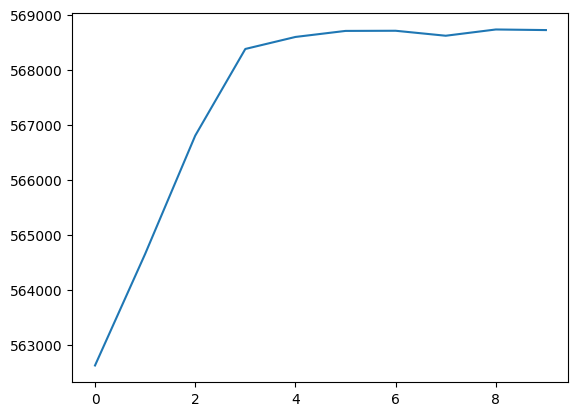

In [26]:
mycebmf31 = cEBMF(data=Z,X_l = X,
                  prior_L = "cgb_sharp",
                  allow_backfitting = False)
mycebmf31.initialise_factors()
mycebmf31.fit(10)

This plot shows the improvement in the ELBO over time:

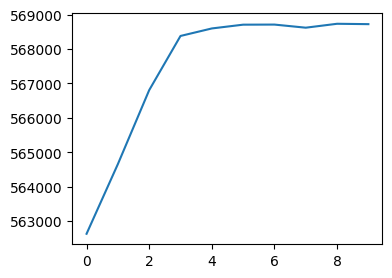

In [31]:
plt.figure(figsize = (4,3))
plt.plot(mycebmf31.obj)

Model 2 uses a "covariate-moderated" prior to learn a matrix factorization accounting in a way that accounts for the side information:

In [32]:
mycebmf11=  cEBMF(data=Z, X_l=X,
                 prior_L="cash" , allow_backfitting=False)
mycebmf11.initialise_factors()
mycebmf11.fit(10)


[CASH] Epoch 10/20 | Loss: 316.9005
[CASH] Epoch 20/20 | Loss: 314.6444
[CASH] Epoch 10/20 | Loss: 208.3581
[CASH] Epoch 20/20 | Loss: 202.2013
[CASH] Epoch 10/20 | Loss: 221.9928
[CASH] Epoch 20/20 | Loss: 213.3573
[CASH] Epoch 10/20 | Loss: 209.3859
[CASH] Epoch 20/20 | Loss: 208.9213
[CASH] Epoch 10/20 | Loss: 208.8459
[CASH] Epoch 20/20 | Loss: 208.5255
[CASH] Epoch 10/20 | Loss: 315.5394
[CASH] Epoch 20/20 | Loss: 312.8163
[CASH] Epoch 10/20 | Loss: 203.2399
[CASH] Epoch 20/20 | Loss: 196.7897
[CASH] Epoch 10/20 | Loss: 214.2642
[CASH] Epoch 20/20 | Loss: 209.5469
[CASH] Epoch 10/20 | Loss: 205.1100
[CASH] Epoch 20/20 | Loss: 205.1033
[CASH] Epoch 10/20 | Loss: 206.1154
[CASH] Epoch 20/20 | Loss: 205.9718
[CASH] Epoch 10/20 | Loss: 315.5513
[CASH] Epoch 20/20 | Loss: 310.6530
[CASH] Epoch 10/20 | Loss: 202.9806
[CASH] Epoch 20/20 | Loss: 196.4818
[CASH] Epoch 10/20 | Loss: 212.9994
[CASH] Epoch 20/20 | Loss: 209.6759
[CASH] Epoch 10/20 | Loss: 202.7428
[CASH] Epoch 20/20 | Loss: 2

CEBMFResult(L=tensor([[-6.8695e+00, -1.4978e-07,  6.0244e-12,  1.1097e-01, -3.5538e-01],
        [-2.4537e-04, -3.8064e-08,  2.2645e+00,  2.5290e-01, -1.0630e-01],
        [-1.9616e+00, -7.4963e-14, -2.2010e-05, -5.3208e-02, -3.1497e-01],
        ...,
        [-6.4651e+00, -1.0077e-08,  3.8342e-12, -7.9673e-02,  6.5728e-01],
        [-1.0889e-04,  3.2110e-06,  2.8003e+00,  1.2418e-01,  1.1639e-01],
        [-3.9726e-05,  4.3760e-06,  1.7189e+00,  8.9730e-03,  9.8424e-02]],
       device='cuda:0'), F=tensor([[-1.3522e-01,  1.5125e-01, -1.0521e-01, -2.5821e-04, -1.6014e-03],
        [ 1.6556e-01,  1.5067e-01,  1.2410e-03, -4.1962e-04, -4.2162e-04],
        [-4.1168e-04, -1.1457e-03,  5.2752e-02,  2.4005e-04, -2.5959e-01],
        [-5.5564e-02,  1.2421e-01,  9.5510e-02, -1.8702e-03, -7.6432e-04],
        [ 7.6905e-06, -3.6415e-02,  8.0072e-02, -1.0090e-03, -1.3535e-03],
        [ 1.0151e-03,  2.6526e-03,  3.0341e-04,  2.6008e-04,  2.6691e-04],
        [-1.4128e-05, -1.2652e-02, -9.2671e-0

The improvement in the ELBO over time is not monotonic for cEBMF because the prior optimization is based on stochastic gradients.

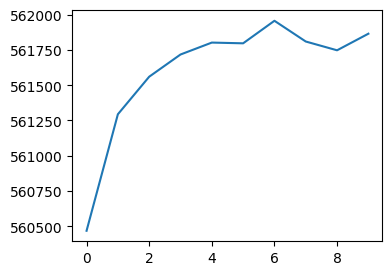

In [33]:
plt.figure(figsize = (4,3))
plt.plot(mycebmf11.obj)

Model 3 incorporates the side information into a "covariate-moderated" variant of the generalized binary prior:

In [34]:
mycebmf12 = cEBMF(data = Z,X_l = X,
                  prior_L = "cgb",
                  allow_backfitting = False)
mycebmf12.initialise_factors()
mycebmf12.fit(10)

[CGB] Epoch 10/50, Loss=2.9939, mu2=-0.154, sigma2=6.625
[CGB] Epoch 20/50, Loss=2.9527, mu2=-0.312, sigma2=6.236
[CGB] Epoch 30/50, Loss=2.9294, mu2=-0.472, sigma2=6.743
[CGB] Epoch 40/50, Loss=2.9157, mu2=-0.635, sigma2=6.326
[CGB] Epoch 50/50, Loss=2.8866, mu2=-0.800, sigma2=5.535
[CGB] Epoch 10/50, Loss=1.7429, mu2=-0.114, sigma2=4.311
[CGB] Epoch 20/50, Loss=1.7060, mu2=-0.231, sigma2=4.669
[CGB] Epoch 30/50, Loss=1.6960, mu2=-0.361, sigma2=4.506
[CGB] Epoch 40/50, Loss=1.6846, mu2=-0.502, sigma2=4.726
[CGB] Epoch 50/50, Loss=1.6777, mu2=-0.650, sigma2=3.911
[CGB] Epoch 10/50, Loss=1.9180, mu2=0.128, sigma2=2.454
[CGB] Epoch 20/50, Loss=1.8413, mu2=0.273, sigma2=2.499
[CGB] Epoch 30/50, Loss=1.8183, mu2=0.431, sigma2=2.417
[CGB] Epoch 40/50, Loss=1.8004, mu2=0.598, sigma2=1.724
[CGB] Epoch 50/50, Loss=1.7876, mu2=0.774, sigma2=2.049
[CGB] Epoch 10/50, Loss=1.7677, mu2=-0.014, sigma2=1.793
[CGB] Epoch 20/50, Loss=1.7704, mu2=-0.033, sigma2=2.661
[CGB] Epoch 30/50, Loss=1.7642, mu2=

CEBMFResult(L=tensor([[-6.7020e+00, -9.4802e-07,  0.0000e+00, -7.6278e-13, -2.3018e-18],
        [-8.8595e-04, -1.9923e-07,  1.2704e+00, -7.4198e-13, -6.1700e-18],
        [-1.9633e+00,  0.0000e+00,  2.6972e-06, -7.6336e-13, -4.2502e-19],
        ...,
        [-6.3180e+00, -4.6196e-07,  0.0000e+00, -8.6391e-13, -2.1446e-18],
        [-3.6407e-04,  1.7704e-05,  1.5067e+00, -2.2363e-13, -4.4495e-18],
        [-5.1251e-05,  4.5683e-05,  1.0636e+00, -1.0517e-13, -1.5169e-18]],
       device='cuda:0'), F=tensor([[-1.3824e-01,  1.7516e-01, -1.8336e-01, -7.9556e-10, -1.6572e-13],
        [ 1.6927e-01,  1.7404e-01,  5.0891e-03,  2.1998e-08,  1.4070e-12],
        [-4.7714e-04, -1.1391e-03,  7.9745e-02, -3.9646e-09, -2.6852e-13],
        [-5.6782e-02,  1.4290e-01,  1.6217e-01,  1.2070e-08,  4.5045e-13],
        [ 1.2537e-05, -4.1987e-02,  1.4312e-01, -1.1322e-08, -4.7922e-13],
        [ 1.0308e-03,  3.0621e-03,  7.2087e-04,  9.0164e-09,  4.4435e-13],
        [-2.2515e-05, -1.4377e-02, -2.4955e-0

Here again we examine the improvement in the ELBO over time:

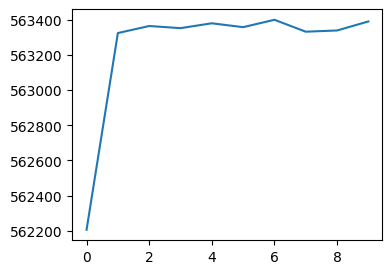

In [35]:
plt.figure(figsize = (4,3))
plt.plot(mycebmf12.obj)

Model 4 uses an "emprirical mixture of density networks" (emdn) prior to incorporate the side information into the prior on ${\bf L}$:

In [36]:
mycebmf13 = cEBMF(data = Z,X_l = X,
                  prior_L = "emdn",
                  allow_backfitting = False)
mycebmf13.initialise_factors()
mycebmf13.fit(10)

[EMDN] Epoch 10/50, Loss: 2.8351
[EMDN] Epoch 20/50, Loss: 2.0805
[EMDN] Epoch 30/50, Loss: 1.6230
[EMDN] Epoch 40/50, Loss: 1.5752
[EMDN] Epoch 50/50, Loss: 1.5475
[EMDN] Epoch 10/50, Loss: 1.7243
[EMDN] Epoch 20/50, Loss: 1.5437
[EMDN] Epoch 30/50, Loss: 1.5115
[EMDN] Epoch 40/50, Loss: 1.4924
[EMDN] Epoch 50/50, Loss: 1.4826
[EMDN] Epoch 10/50, Loss: 1.6842
[EMDN] Epoch 20/50, Loss: 1.6021
[EMDN] Epoch 30/50, Loss: 1.5067
[EMDN] Epoch 40/50, Loss: 1.4936
[EMDN] Epoch 50/50, Loss: 1.4915
[EMDN] Epoch 10/50, Loss: 1.6817
[EMDN] Epoch 20/50, Loss: 1.6799
[EMDN] Epoch 30/50, Loss: 1.6780
[EMDN] Epoch 40/50, Loss: 1.6763
[EMDN] Epoch 50/50, Loss: 1.6768
[EMDN] Epoch 10/50, Loss: 1.6788
[EMDN] Epoch 20/50, Loss: 1.6771
[EMDN] Epoch 30/50, Loss: 1.6744
[EMDN] Epoch 40/50, Loss: 1.6726
[EMDN] Epoch 50/50, Loss: 1.6674
[EMDN] Epoch 10/50, Loss: 2.7436
[EMDN] Epoch 20/50, Loss: 1.8557
[EMDN] Epoch 30/50, Loss: 1.5847
[EMDN] Epoch 40/50, Loss: 1.5557
[EMDN] Epoch 50/50, Loss: 1.5210
[EMDN] Epo

CEBMFResult(L=tensor([[-7.1387, -0.0958,  0.0232, -0.1459, -0.1447],
        [-0.4489, -0.0889,  3.4456,  0.2757, -0.2747],
        [-3.2850, -0.0506, -0.0242, -0.2181, -0.2116],
        ...,
        [-6.5393, -0.0783,  0.0148, -0.2786,  0.1505],
        [-0.2492, -0.0600,  3.3653,  0.1273,  0.7680],
        [-0.2317, -0.0518,  3.0573, -0.1838,  0.3786]], device='cuda:0'), F=tensor([[-1.3505e-01,  1.7626e-01, -1.0226e-01,  7.7557e-04, -1.2652e-03],
        [ 1.6077e-01,  1.3441e-01,  3.5174e-02, -2.3011e-04, -4.5025e-03],
        [-5.7457e-04, -1.8327e-03,  4.7173e-02,  2.2479e-04, -2.7174e-01],
        [-5.6922e-02,  1.4228e-01,  8.0736e-02, -1.1575e-03, -7.4475e-03],
        [ 5.1794e-05, -3.7136e-02,  7.4917e-02, -1.3952e-03, -4.5904e-04],
        [ 1.1838e-03,  3.4895e-03,  1.3167e-03,  5.2309e-04,  9.4924e-04],
        [ 3.0993e-05, -1.4067e-02, -2.7942e-03, -1.4570e-01,  4.3922e-03],
        [-1.9164e-01,  1.8640e-01,  1.3151e-02,  2.7867e-04,  5.5068e-04],
        [-1.0496e-04, 

Let's now compare the ${\bf L}$ matrix from Model 1, which does not exploit the side information, and the ${\bf L}$ from Model 4, which does make use of the side information. These are the results from Model 1:

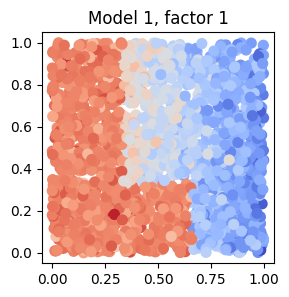

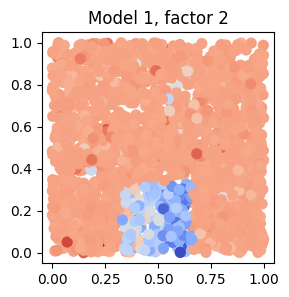

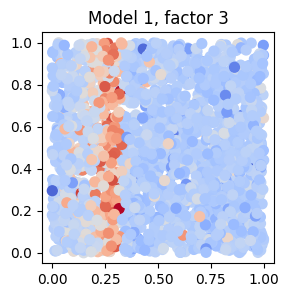

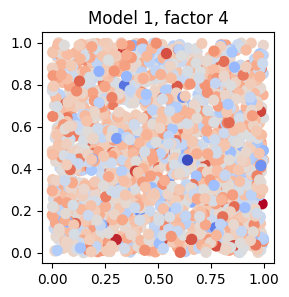

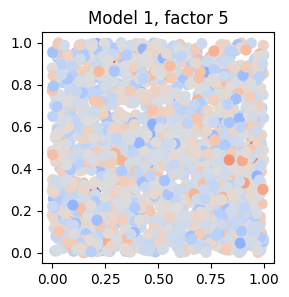

In [49]:
for i in range(0,5):
    plt.figure(figsize = (3,3))
    plt.title(f"Model 1, factor {i+1}")
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c = mycebmf.L[:, i].cpu().numpy(),
        cmap="coolwarm",
        s=50
    )

And these are the results from Model 4:

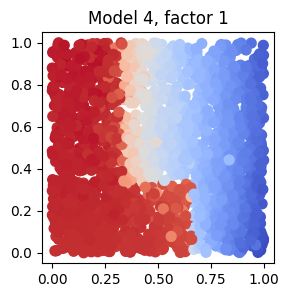

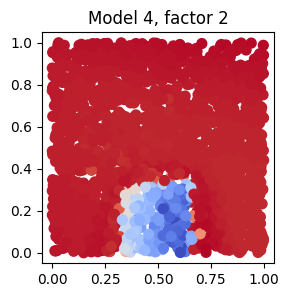

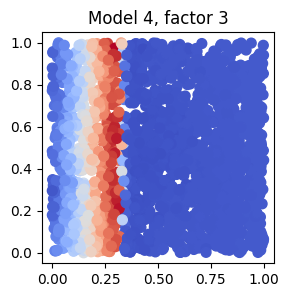

In [51]:
for i in range(3):
    plt.figure(figsize = (3,3))
    plt.title(f"Model 4, factor {i+1}")
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf13.L[:, i].cpu().numpy(),
        cmap="coolwarm",
        s=50
    )


While both models have recovered the overall structure of the simulated data, Model 4, by making use of the side information, recovers the structure much more accurately.